<a href="https://colab.research.google.com/github/HazemmoAlsady/AWN_Graduation_Project/blob/main/03_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cleaned Parquet
#       ↓
#Feature Engineering
   #    ↓
#ML Training
  #     ↓
#Evaluation
 #      ↓
#Best Model

In [34]:
!pip install pyspark --quiet
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
    StandardScaler
)

from pyspark.ml import Pipeline

from pyspark.ml.regression import (
    LinearRegression,
    DecisionTreeRegressor,
    RandomForestRegressor,
    GBTRegressor
)

from pyspark.ml.evaluation import (
    RegressionEvaluator
)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import builtins

In [35]:
spark = SparkSession.builder \
    .appName("RetailML") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
import os

os.listdir("/content/drive/MyDrive")

['online_retail_II.csv', 'models', 'Colab Notebooks', 'bigdata_project']

In [38]:
data = spark.read.parquet(
    "/content/drive/MyDrive/bigdata_project"
)

print(data.count())

data.show(5)

779425
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+----------+----+-----+-------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer_ID|       Country|TotalPrice|Year|Month|Quarter|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+----------+----+-----+-------+
| 489460|    84568|GIRLS ALPHABET IR...|     288|2009-12-01 10:46:00| 0.21|    16167.0|United Kingdom|     60.48|2009|   12|      4|
| 489537|    20829|GLITTER HANGING B...|       6|2009-12-01 12:14:00|  2.1|    14040.0|United Kingdom|      12.6|2009|   12|      4|
| 489560|    90087|CRYSTAL SEA HORSE...|      48|2009-12-01 12:56:00| 0.85|    13526.0|United Kingdom|      40.8|2009|   12|      4|
| 489572|    22079|RIBBON REEL HEART...|       5|2009-12-01 13:29:00| 1.65|    17611.0|United Kingdom|      8.25|2009|   12|      4|
| 489573|    21625|VINTAGE UNION JAC...|       7|2009-12-01 13

# Select ML Features

In [39]:
ml_data = data.select(
    "Price",
    "Month",
    "Quarter",
    "Year",
    "Country",
    "Quantity"
).dropna()

In [40]:
q1, q3 = ml_data.approxQuantile(
    "Quantity",
    [0.25, 0.75],
    0.05
)

iqr = q3 - q1

In [41]:
ml_data = ml_data.withColumn(
    "Quantity",

    when(
        col("Quantity") < q1 - 1.5*iqr,
        q1 - 1.5*iqr
    )

    .when(
        col("Quantity") > q3 + 1.5*iqr,
        q3 + 1.5*iqr
    )

    .otherwise(col("Quantity"))
)

In [42]:
indexer = StringIndexer(
    inputCol="Country",
    outputCol="Country_index",
    handleInvalid="keep"
)

In [43]:
encoder = OneHotEncoder(
    inputCols=["Country_index"],
    outputCols=["Country_ohe"]
)

In [44]:
assembler = VectorAssembler(
    inputCols=[
        "Price",
        "Month",
        "Quarter",
        "Year",
        "Country_ohe"
    ],
    outputCol="features_raw"
)

In [45]:
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=False
)

In [46]:
pipeline = Pipeline(
    stages=[
        indexer,
        encoder,
        assembler,
        scaler
    ]
)

In [47]:
prep_model = pipeline.fit(ml_data)

ml_ready = prep_model.transform(ml_data)

In [48]:
ml_ready = ml_ready.withColumnRenamed(
    "Quantity",
    "label"
)

In [49]:
train_data, test_data = ml_ready.randomSplit(
    [0.8, 0.2],
    seed=42
)

In [50]:
print(train_data.count())
print(test_data.count())

623738
155687


In [51]:
evaluator_r2 = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="r2"
)

In [52]:
evaluator_rmse = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="rmse"
)

In [53]:
evaluator_mae = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="mae"
)

# Train Models

In [54]:
results = {}

def evaluate(name, model, test):

    preds = model.transform(test)

    r2 = evaluator_r2.evaluate(preds)
    rmse = evaluator_rmse.evaluate(preds)
    mae = evaluator_mae.evaluate(preds)

    results[name] = {
    "R2": __builtins__.round(r2, 4),
    "RMSE": __builtins__.round(rmse, 2),
    "MAE": __builtins__.round(mae, 2)
    }

    print(
        f"{name} | "
        f"R2={r2:.4f} | "
        f"RMSE={rmse:.2f} | "
        f"MAE={mae:.2f}"
    )

In [55]:
lr = LinearRegression(
    featuresCol="features",
    labelCol="label"
)

lr_model = lr.fit(train_data)

evaluate(
    "Linear Regression",
    lr_model,
    test_data
)

Linear Regression | R2=0.0347 | RMSE=7.93 | MAE=6.34


In [56]:
dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol="label"
)

dt_model = dt.fit(train_data)

evaluate(
    "Decision Tree",
    dt_model,
    test_data
)

Decision Tree | R2=0.2744 | RMSE=6.88 | MAE=5.17


In [57]:
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="label",
    numTrees=20
)

rf_model = rf.fit(train_data)

evaluate(
    "Random Forest",
    rf_model,
    test_data
)

Random Forest | R2=0.2263 | RMSE=7.10 | MAE=5.42


In [58]:
gbt = GBTRegressor(
    featuresCol="features",
    labelCol="label",
    maxIter=20
)

gbt_model = gbt.fit(train_data)

evaluate(
    "GBT",
    gbt_model,
    test_data
)

GBT | R2=0.2961 | RMSE=6.77 | MAE=5.08


In [59]:
results_df = pd.DataFrame(results).T

results_df

,R2,RMSE,MAE
Linear Regression,0.0347,7.93,6.34
Decision Tree,0.2744,6.88,5.17
Random Forest,0.2263,7.10,5.42
GBT,0.2961,6.77,5.08


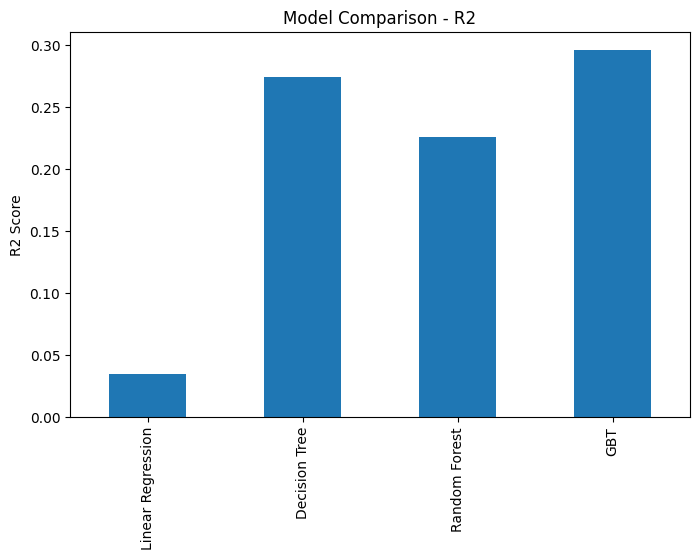

In [60]:
results_df["R2"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison - R2")

plt.ylabel("R2 Score")

plt.show()

In [62]:
best_model = __builtins__.max(
    results,
    key=lambda x: results[x]["R2"]
)

In [63]:
preds = gbt_model.transform(test_data)

In [64]:
preds.select(
    "label",
    "prediction"
).show(10)

+-----+------------------+
|label|        prediction|
+-----+------------------+
|  1.0| 20.54116341475564|
|  1.0| 20.54116341475564|
|  1.0| 20.54116341475564|
|  1.0|20.497578259827872|
| 27.0|20.497578259827872|
| 27.0| 19.94081843150217|
| 27.0|24.360628890594402|
| 27.0| 19.94081843150217|
| 27.0| 20.01390759590966|
| 27.0| 20.01390759590966|
+-----+------------------+
only showing top 10 rows


In [66]:
results_df.to_csv(
    "/content/drive/MyDrive/bigdata_project/ml_results.csv"
)